# Interactive Visualization with Plotly

Plotly is a Python library used for creating interactive visualizations (graphs & charts). Unlike Matplotlib and Seaborn which create static images, Plotly renders an HTML document and uses JavaScript under the hood to enable interactivity. Plotly also offers a large selection of chart types to choose from.

In [1]:
!pip install plotly -q

In [2]:
# @title
import numpy as np
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots

np.random.seed(42)

resolution_times = np.random.exponential(scale=4.0, size=500) + 0.5
df_history = pd.DataFrame({"Resolution_Hours": resolution_times})


resp_mins = np.random.uniform(1, 15, 120)
csat_scores = 100 - (resp_mins * 3.5) + np.random.normal(0, 5, 120)
csat_scores = np.clip(csat_scores, 10, 100)
df_scatter = pd.DataFrame({"Response_Minutes": resp_mins, "CSAT_Score": csat_scores})

hours = np.arange(0, 24)
incoming = 50 + 35 * np.sin(hours / 3) + np.random.normal(0, 5, 24)
resolved = 45 + 30 * np.sin((hours - 1) / 3) + np.random.normal(0, 4, 24)

df_lines = pd.DataFrame({
    "Hour": hours,
    "Incoming_Tickets": incoming,
    "Resolved_Tickets": resolved
})

departments = ["Billing", "Technical Support", "Account Access", "Integrations", "Sales Queries"]
ticket_counts = [1420, 2850, 890, 610, 1150]
df_categories = pd.DataFrame({"Department": departments, "Ticket_Count": ticket_counts})


fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Distribution of Resolution Times",
        "CSAT Score vs. First Response Time",
        "24-Hour Operational Flow",
        "Ticket Volume by Department"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.12
)


px_hist = px.histogram(df_history, x="Resolution_Hours", nbins=25)
px_hist.update_traces(marker_color="#0284c7", marker_line_color="#ffffff", marker_line_width=0.5)
fig.add_trace(px_hist.data[0], row=1, col=1)

px_scatter = px.scatter(df_scatter, x="Response_Minutes", y="CSAT_Score")
px_scatter.update_traces(marker=dict(size=8, color="#dc2626", opacity=0.7))
fig.add_trace(px_scatter.data[0], row=1, col=2)

px_line_in = px.line(df_lines, x="Hour", y="Incoming_Tickets")
px_line_in.update_traces(line=dict(color="#2563eb", width=3), name="Incoming")

px_line_res = px.line(df_lines, x="Hour", y="Resolved_Tickets")
px_line_res.update_traces(line=dict(color="#16a34a", width=3, dash="dash"), name="Resolved")

fig.add_trace(px_line_in.data[0], row=2, col=1)
fig.add_trace(px_line_res.data[0], row=2, col=1)

px_bar = px.bar(df_categories, x="Department", y="Ticket_Count")
px_bar.update_traces(marker_color="#7c3aed", width=0.6)
fig.add_trace(px_bar.data[0], row=2, col=2)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=800,
    showlegend=False,
    margin=dict(l=60, r=40, t=80, b=60)
)

for title in fig['layout']['annotations']:
    title['font'] = dict(size=14, color="#111827", family="Arial")

fig.update_xaxes(title_text="Hours to Close Ticket", row=1, col=1)
fig.update_yaxes(title_text="Number of Tickets", row=1, col=1)

fig.update_xaxes(title_text="First Response Time (Mins)", row=1, col=2)
fig.update_yaxes(title_text="CSAT Score (0-100)", row=1, col=2)

fig.update_xaxes(title_text="Hour of Day (24h)", row=2, col=1)
fig.update_yaxes(title_text="Ticket Count", row=2, col=1)

fig.update_xaxes(title_text="Department Tier", row=2, col=2)
fig.update_yaxes(title_text="Total Open Volume", row=2, col=2)

fig.update_xaxes(showgrid=True, gridcolor="#e5e7eb", zeroline=False)
fig.update_yaxes(showgrid=True, gridcolor="#e5e7eb", zeroline=False)

fig.show()

The following topics are covered in this tutorial:

- Creating figures & adding interactive elements
- A quick tour of popular interactive charts
- Using Plotly as a plotting backend for Pandas
- Creating and exploring 3D graphs
- Adding controls and animating graphs

## Creating Figures and Adding Interactive Elements

Like Matplotlib, Plotly provides several low-level functions for creating and customizing figures. While they offer fine grained control over various aspects of a graph, they're quite verbose and can be cumbersome to use. We'll start out by using Plotly express, a high-level API similar to Seaborn, that allows creating and customizing charts with a single line of code.

Plotly express is often imported using the alias `px`.

In [3]:
import plotly.express as px

Plotly Express Doc: https://plotly.com/python/plotly-express/

Let's download a [country-wise population dataset](https://data.worldbank.org/indicator/SP.POP.TOTL) from World Bank Open Data.

In [4]:
!wget -q https://api.worldbank.org/v2/en/indicator/SP.POP.TOTL?downloadformat=csv -O population.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
population_csv_url = 'https://raw.githubusercontent.com/nawaz0x1/Quantropy/refs/heads/main/Data%20Visualization/data/population.csv'
population_df = pd.read_csv(population_csv_url, index_col = "Year")
population_df.head()

,Aruba,Africa Eastern and Southern,Afghanistan,Africa Western and Central,Angola,Albania,Andorra,Arab World,United Arab Emirates,Argentina,...,Virgin Islands (U.S.),Viet Nam,Vanuatu,World,Samoa,Kosovo,"Yemen, Rep.",South Africa,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
1960,54922.0,130075728.0,9035043.0,97630925.0,5231654.0,1608800.0,9510.0,91540853.0,131334.0,20386045.0,...,32500.0,32531933.0,64431.0,3.021513e+09,112490.0,984846.0,5532301.0,16440172.0,3153729.0,3809389.0
1961,55578.0,133534923.0,9214083.0,99706674.0,5301583.0,1659800.0,10283.0,93931683.0,137989.0,20726276.0,...,34300.0,33409059.0,66264.0,3.062768e+09,115496.0,1011421.0,5655232.0,16908035.0,3254086.0,3930401.0
1962,56320.0,137171659.0,9404406.0,101854756.0,5354310.0,1711319.0,11086.0,96428599.0,144946.0,21072538.0,...,35000.0,34288560.0,68174.0,3.117372e+09,118597.0,1036950.0,5782221.0,17418522.0,3358099.0,4055959.0
1963,57002.0,140945536.0,9604487.0,104089175.0,5408320.0,1762621.0,11915.0,99038509.0,152211.0,21421705.0,...,39800.0,35249101.0,70159.0,3.184063e+09,121764.0,1062737.0,5911135.0,17954564.0,3465907.0,4185877.0
1964,57619.0,144904094.0,9814318.0,106388440.0,5464187.0,1814135.0,12764.0,101729760.0,159692.0,21769453.0,...,40800.0,36201563.0,72219.0,3.251253e+09,124894.0,1090270.0,6048006.0,18511361.0,3577017.0,4320006.0


In [6]:
px.line(population_df['Bangladesh'] , title="Population")

In [7]:
population_df.tail(5)

,Aruba,Africa Eastern and Southern,Afghanistan,Africa Western and Central,Angola,Albania,Andorra,Arab World,United Arab Emirates,Argentina,...,Virgin Islands (U.S.),Viet Nam,Vanuatu,World,Samoa,Kosovo,"Yemen, Rep.",South Africa,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
2022,107310.0,731821393.0,40578842.0,497387180.0,35635029.0,2451636.0,79705.0,471352066.0,10074977.0,45407904.0,...,105413.0,99680655.0,313046.0,7.989545e+09,215261.0,1768096.0,38222876.0,62378410.0,20152938.0,16069056.0
2023,107359.0,750491370.0,41454761.0,509398589.0,36749906.0,2414095.0,80856.0,482105978.0,10483751.0,45538401.0,...,104917.0,100352192.0,320409.0,8.064058e+09,216663.0,1682668.0,39390799.0,63212384.0,20723965.0,16340822.0
2024,107995.0,769280888.0,42647492.0,521764076.0,37885849.0,2377128.0,81938.0,492612632.0,10986400.0,45696159.0,...,104377.0,100987686.0,327777.0,8.141809e+09,218019.0,1594353.0,40583164.0,64007187.0,21314956.0,16634373.0
2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dropping the last 2 columns as they dont have any values 

In [8]:
population_df.drop(population_df.tail(2).index,axis=0,inplace=True)

In [9]:
population_df.tail(2)

,Aruba,Africa Eastern and Southern,Afghanistan,Africa Western and Central,Angola,Albania,Andorra,Arab World,United Arab Emirates,Argentina,...,Virgin Islands (U.S.),Viet Nam,Vanuatu,World,Samoa,Kosovo,"Yemen, Rep.",South Africa,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
2023,107359.0,750491370.0,41454761.0,509398589.0,36749906.0,2414095.0,80856.0,482105978.0,10483751.0,45538401.0,...,104917.0,100352192.0,320409.0,8.064058e+09,216663.0,1682668.0,39390799.0,63212384.0,20723965.0,16340822.0
2024,107995.0,769280888.0,42647492.0,521764076.0,37885849.0,2377128.0,81938.0,492612632.0,10986400.0,45696159.0,...,104377.0,100987686.0,327777.0,8.141809e+09,218019.0,1594353.0,40583164.0,64007187.0,21314956.0,16634373.0


In [10]:
px.line(population_df['Bangladesh'] , title="Population")


In [13]:
px.line(population_df['Ireland'], title="Population")

Note the following:

* `px.line` automatically picks the index of the series as the X-axis.
* You can hover over any point on the line to view the exact value.
* You can Zoom in and out using the controls to take a closer look at specific areas of the chart.
* There are several other controls e.g pan, autoscale, download PNG etc.

For fine grained control over various aspects of the chart, we can use the Figure object returned by `px.line`. Let's change the axis labels, chart colors, and ensure that the y axis starts at 0.

In [11]:
fig=px.line(population_df['Bangladesh'])

In [12]:
# Set axis & legend labels
fig.update_layout(
    title="Year-Wise Population",
    xaxis_title="Year",
    yaxis_title="Population",
    legend_title="Country",
    plot_bgcolor='#dedddc',
    font=dict(
        family="Arial",
        size=14,
        color="#040d78"
    )
)

# Start the Y axis from 0
fig.update_yaxes(rangemode='tozero')

Here's a list of properties you can set using `update_layout`: https://plotly.com/python/reference/layout/

Plotly also has built-in support for Pandas dataframes.

In [13]:
europe_df = population_df[['Italy', 'Germany', 'Switzerland']]
europe_df.head()

,Italy,Germany,Switzerland
Year,,,
1960,50199700.0,72814900.0,5327827.0
1961,50536350.0,73377632.0,5434294.0
1962,50879450.0,74025784.0,5573815.0
1963,51252000.0,74714353.0,5694247.0
1964,51675350.0,75318337.0,5789228.0


In [14]:
fig = px.line(europe_df,
              title='Population',
              color_discrete_sequence=["green", "cornflowerblue", "red"]
              )

fig.update_layout(yaxis_title='Population',
                  legend_title='Countries',
                  font_size=14)

fig.update_yaxes(rangemode='tozero')

fig.show()

Note that apart from providing RGB hexcodes for colors, we can also use named CSS colors: https://www.w3schools.com/cssref/css_colors.php

Switching from a line chart to a bar chart is simply a matter of replacing `plt.line` with `plt.bar`.

In [15]:
px.bar(population_df[['Bangladesh', 'Pakistan']],
       title="Population",
       barmode='group'
       )

EXERCISE: Compare the annual population increase of India and China using a line chart. Which of the two countries is growing faster? Hint: Use population_df.diff()

In [16]:
px.line(population_df[['India','China']])

In [17]:
px.line(population_df[['India','China']].diff(),title="Population Growth")

> **EXERCISE**: Compare the populations of 10 most populous African countries over the last 50 years using line charts.

In [18]:
african_countries = [
    'Nigeria', 'Ethiopia', 'Egypt, Arab Rep.', 'Congo, Dem. Rep.',
    'South Africa', 'Tanzania', 'Kenya', 'Algeria', 'Uganda',
    'Sudan', 'Morocco', 'Angola', 'Ghana', 'Mozambique', 'Madagascar'
]

african_population = population_df[african_countries]
african_population_50 = african_population.dropna().tail(50)

In [19]:
african_population_50

,Nigeria,Ethiopia,"Egypt, Arab Rep.","Congo, Dem. Rep.",South Africa,Tanzania,Kenya,Algeria,Uganda,Sudan,Morocco,Angola,Ghana,Mozambique,Madagascar
Year,,,,,,,,,,,,,,,
1975,63410815.0,31723252.0,38875327.0,23021101.0,25690940.0,16138361.0,13511671.0,15678596.0,11725240.0,14064798.0,17150786.0,6842947.0,10294308.0,9540817.0,7739336.0
1976,65258009.0,32534418.0,39795557.0,23624031.0,26395450.0,16736211.0,13957623.0,16409170.0,12037294.0,14569716.0,17574182.0,7074664.0,10594913.0,9867209.0,7976831.0
1977,67234590.0,33167272.0,40748870.0,24229061.0,27118952.0,17352929.0,14428819.0,17015994.0,12359669.0,15086614.0,18014756.0,7317829.0,10911871.0,10224975.0,8222240.0
1978,69326532.0,33734592.0,41761431.0,24992689.0,27869507.0,17976566.0,14934126.0,17506974.0,12692113.0,15695003.0,18477385.0,7576734.0,11248450.0,10618250.0,8475864.0
1979,71498242.0,34238652.0,42818628.0,25886782.0,28634162.0,18592038.0,15460666.0,18036655.0,13002163.0,16355352.0,18955589.0,7847207.0,11597255.0,11028809.0,8737581.0
1980,73764641.0,34428514.0,43950413.0,26711099.0,29518857.0,19189769.0,16018459.0,18607174.0,13275741.0,17058905.0,19459943.0,8133872.0,11941448.0,11336221.0,9006032.0
1981,76068103.0,35304012.0,45147224.0,27500515.0,30541044.0,19784703.0,16601507.0,19220704.0,13556452.0,17780572.0,19985401.0,8435607.0,12281712.0,11568127.0,9279011.0
1982,78378701.0,36701290.0,46407611.0,28338190.0,31615339.0,20398571.0,17206175.0,19872348.0,13873631.0,18486645.0,20520318.0,8751648.0,12643819.0,11824370.0,9557671.0
1983,80438260.0,37740817.0,47786402.0,29250963.0,32739304.0,21079874.0,17846374.0,20558115.0,14221881.0,19109770.0,21060696.0,9082983.0,13029836.0,12073822.0,9843044.0


In [22]:
fig = px.line(african_population_50,
              title="Population of last 10 years of African countries",
              labels={'value':'Total Population', 'Year':'Year','variable':'Country'})

fig.show()

## A quick tour of popular interactive charts

Plotly express provides more than 30 figure for creating different types of figures. Let's explore some popular interactive visualization techniques. We'll use the [built-in datasets](https://plotly.com/python-api-reference/generated/plotly.express.data.html) from `px.data` to demonstrate their usage.

### Scatter Plot

In [23]:
iris_df = px.data.iris()
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,3
146,6.3,2.5,5.0,1.9,virginica,3
147,6.5,3.0,5.2,2.0,virginica,3
148,6.2,3.4,5.4,2.3,virginica,3


In [ ]:
px.scatter(iris_df,
           x="sepal_width",
           y="sepal_length",
           color="species", # For seaborn it was hue 
           size='petal_length', # which size we want for the dots
           hover_data=['petal_width','species_id']) # what extra columns we wanna show pass this into this array

### Bar Chart

We'll use the dataset `medals_long`, which contains represents the medal table for Olympic Short Track Speed Skating for the top three nations as of 2026.

In [25]:
long_df = px.data.medals_long()
long_df

,nation,medal,count
0,South Korea,gold,24
1,China,gold,10
2,Canada,gold,9
3,South Korea,silver,13
4,China,silver,15
5,Canada,silver,12
6,South Korea,bronze,11
7,China,bronze,8
8,Canada,bronze,12


In [31]:
fig = px.bar(long_df,
             x="nation",
             y="count",
             color="medal",
             title="Olympic Short Track Speed Skating Medals",
             color_discrete_sequence=["#FFD900", "#B4B4B4", "#F1A642"])
fig.show()

### Treemap and Sunburst

In [32]:
gapminder_df = px.data.gapminder().query("year == 2007")
gapminder_df["world"] = "World"
gapminder_df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num,world
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4,World
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8,World
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12,World
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24,World
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32,World
...,...,...,...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404,VNM,704,World
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798,PSE,275,World
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906,YEM,887,World
1691,Zambia,Africa,2007,42.384,11746035,1271.211593,ZMB,894,World


In [33]:
fig = px.treemap(gapminder_df,
                 path=['world','continent', 'country'],
                 values='pop',
                 color='lifeExp',
                 color_continuous_scale='RdBu')
fig.show()

In [40]:
fig = px.sunburst(gapminder_df,
                 path=[ 'continent', 'country'],
                 values='pop',
                 color='lifeExp',
                 color_continuous_scale='Agsunset')
fig.show()

Learn more about Treemap and Sunburst charts here:

* https://plotly.com/python/treemaps/
* https://plotly.com/python/sunburst-charts/


In [41]:
tips_df = px.data.tips()
tips_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### Histogram

In [42]:
fig = px.histogram(tips_df,
                   x="total_bill",
                   color="sex",
                   hover_data=tips_df.columns)
fig.show()

### Polar Chart

In [43]:
wind_df = px.data.wind()
wind_df

,direction,strength,frequency
0,N,0-1,0.5
1,NNE,0-1,0.6
2,NE,0-1,0.5
3,ENE,0-1,0.4
4,E,0-1,0.4
...,...,...,...
123,WSW,6+,0.1
124,W,6+,0.9
125,WNW,6+,2.2
126,NW,6+,1.5


In [ ]:
fig = px.line_polar(wind_df,
                    r="frequency", # Readious 
                    theta="direction", # Outside values ( directions )
                    color="strength", # Strength 
                    line_close=True,
                    color_discrete_sequence=px.colors.sequential.Plasma_r,
                    template="plotly_dark")
fig.show()

## Using Plotly as a plotting backend for Pandas

We can configure Pandas to use Plotly as the backend for the `plot` methods of Pandas data frames & series. You can learn more about this here: https://plotly.com/python/pandas-backend/.

The Plotly backend can be enabled as follows:

<Axes: title={'center': 'Population'}, xlabel='Year'>

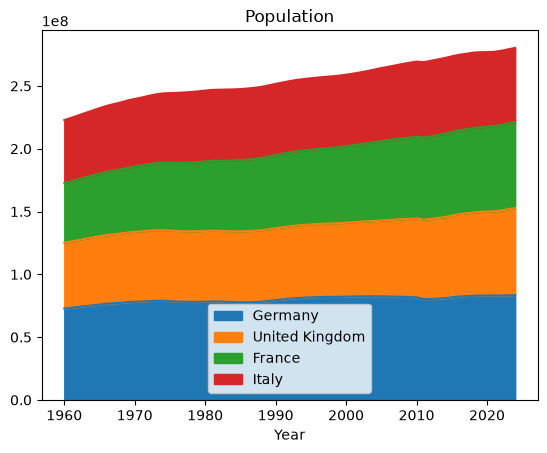

In [45]:
europe_df = population_df[['Germany', 'United Kingdom', 'France', 'Italy']]

europe_df.plot(kind='area', title="Population")

In [ ]:
pd.options.plotting.backend = "plotly" # uses plotly in backend for pandas `    `

In [47]:
europe_df = population_df[['Germany', 'United Kingdom', 'France', 'Italy']]

europe_df.plot(kind='area', title="Population")

In [48]:
tips_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [49]:
fig = tips_df.plot('total_bill',
                   kind='hist',
                   title="Distribution of Total Bill")
fig.update_layout(bargap=0.1)
fig.show()

In [53]:
tips_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [60]:
day_order = ["Thur", "Fri", "Sat", "Sun"]

fig = px.box(
    tips_df,
    x="day",
    y="tip",
    color="sex",
    category_orders={"day": day_order},
    points="outliers",  # use "all" if you want every point shown
    notched=True,
    color_discrete_map={"Male": "#2563eb", "Female": "#ec4899"},
    title="Tip Distribution by Day and Sex",
    labels={"day": "Day of Week", "tip": "Tip ($)", "sex": "Sex"}
)

fig.update_traces(
    marker=dict(size=5, opacity=0.6),
    line=dict(width=1.5)
)

fig.update_layout(
    template="plotly_white",
    width=900,
    height=550,
    boxmode="group",
    legend_title_text="Sex",
    title_x=0.5,
    font=dict(size=14),
    yaxis=dict(gridcolor="lightgray")
)

fig.show()

## Creating and exploring 3D graphs

Plotly can also be used to create 3D graphs. Let's look at an example of 3D surface plots, by plotting the elevation of a mountain.

In [61]:
import pandas as pd

z_data = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/api_docs/mt_bruno_elevation.csv', index_col=0)
z_data

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,27.809850,49.619360,83.080670,116.66320,130.41400,150.72060,220.18710,156.15360,148.64160,203.78450,...,49.961420,21.89279,17.025520,11.743170,14.752260,13.667100,5.677561,3.312340,1.156517,-0.147662
1,27.719660,48.550220,65.213740,95.27666,116.99640,133.90560,152.34120,151.93400,160.11390,179.53270,...,33.088710,38.40972,44.248430,69.578600,4.019351,3.050024,3.039719,2.996142,2.967954,1.999594
2,30.426700,33.477520,44.809530,62.47495,77.43523,104.21530,102.73930,137.00040,186.07060,219.31730,...,48.471320,74.71461,60.090900,7.073525,6.089851,6.537450,6.666096,7.306965,5.736840,3.625628
3,16.665490,30.108600,39.969520,44.12225,59.57512,77.56929,106.89250,166.55390,175.23810,185.28150,...,60.559160,55.92124,15.172840,8.248324,36.680870,61.934130,20.268670,68.588190,46.498120,0.236010
4,8.815617,18.351600,8.658275,27.58590,48.62691,60.18013,91.32860,145.71090,116.06530,106.26620,...,47.426910,69.20731,44.954680,29.171970,17.916740,16.255150,14.655590,17.260480,31.222450,46.717040
5,6.628881,10.413390,24.819390,26.08952,30.16050,52.30802,64.71007,76.30823,84.63686,99.43240,...,140.264700,81.26501,56.457560,30.421640,17.287820,8.302431,2.981626,2.698536,5.886086,5.268358
6,21.839750,6.639270,18.970850,32.89204,43.15014,62.86014,104.66570,130.22940,114.84940,106.98730,...,122.422100,123.96980,109.095200,98.419560,77.613740,32.490310,14.673440,7.370775,0.037110,0.642339
7,53.343030,26.797970,6.639270,10.88787,17.20440,56.18116,79.70141,90.84530,98.27675,80.87243,...,68.174900,46.24076,39.938570,31.216530,36.883350,40.025250,117.429700,12.703280,1.729771,0.000000
8,25.667850,63.057170,22.141400,17.07400,41.74483,60.27227,81.42432,114.44400,102.32340,101.78780,...,59.193550,42.47175,14.635980,6.944074,6.944075,27.749360,0.000000,0.000000,0.094494,0.077323
9,12.827000,69.205540,46.762930,13.96517,33.88744,61.82613,84.74799,121.12200,145.27410,153.17970,...,79.344250,25.93483,6.944074,6.944074,6.944075,7.553681,0.000000,0.000000,0.000000,0.000000


We need to use the low level `graph_objects` API to create a 3d surface and attach it to a figure.

In [62]:
import plotly.graph_objects as go

surface=go.Surface(z=z_data.values)
fig = go.Figure(surface)
fig.update_layout(title='Mt. Bruno Elevation')
fig.show()

Plotly express can be used to create 3D linear and scatter plots.

In [63]:
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,3
146,6.3,2.5,5.0,1.9,virginica,3
147,6.5,3.0,5.2,2.0,virginica,3
148,6.2,3.4,5.4,2.3,virginica,3


In [64]:
px.scatter_3d(iris_df,
              x='sepal_length',
              y='sepal_width',
              z='petal_width', color='species')

## Adding controls and animating graphs

Plotly express graphs can be animated by specifying an `animation_frame` column. Additionally, an `animation_group` can be specified to uniquely identify objects across frames. An animated graph also provides slider controls to skip to any frame.

In [65]:
df = px.data.gapminder()
df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


In [ ]:
df = px.data.gapminder()

fig = px.scatter(df,
                 x="gdpPercap",
                 y="lifeExp",
                 animation_frame="year",
                 animation_group="country",# if any value of a country gets missing in a year, the point will not vanish rather stay in the same place as its previous year 
                 #size="pop",
                 color="continent",
                 hover_name="country",
                 log_x=True, # to scale the value , to brings values from exponential to linear
                 range_x=[100,50000],
                 range_y=[25,80]
                 )

fig.show()

In [74]:
px.box(tips_df, x='sex', y='total_bill', color='smoker', animation_frame='day')

In [75]:
day_order = ["Thur", "Fri", "Sat", "Sun"]

fig = px.box(
    tips_df,
    x="sex",
    y="total_bill",
    color="smoker",
    animation_frame="day",
    category_orders={"day": day_order, "sex": ["Male", "Female"], "smoker": ["Yes", "No"]},
    color_discrete_map={"Yes": "#ef4444", "No": "#2563eb"},
    points="outliers",
    notched=True,
    title="Total Bill Distribution by Sex, Smoker Status, and Day",
    labels={
        "sex": "Sex",
        "total_bill": "Total Bill ($)",
        "smoker": "Smoker",
        "day": "Day"
    },
)

fig.update_traces(
    marker=dict(size=5, opacity=0.6),
    line=dict(width=1.5),
    whiskerwidth=0.7
)

fig.update_layout(
    template="plotly_white",
    width=950,
    height=600,
    boxmode="group",
    title_x=0.5,
    legend_title_text="Smoker",
    font=dict(size=14),
    xaxis_title="Sex",
    yaxis_title="Total Bill ($)",
    transition=dict(duration=700, easing="cubic-in-out"),
    updatemenus=[dict(
        type="buttons",
        showactive=False,
        buttons=[
            dict(label="Play", method="animate",
                 args=[None, {"frame": {"duration": 900, "redraw": True},
                              "transition": {"duration": 700, "easing": "cubic-in-out"},
                              "fromcurrent": True,
                              "mode": "immediate"}]),
            dict(label="Pause", method="animate",
                 args=[[None], {"frame": {"duration": 0, "redraw": False},
                                "transition": {"duration": 0},
                                "mode": "immediate"}])
        ]
    )],
)

fig.update_yaxes(gridcolor="lightgray", zeroline=False)
fig.show()

Learn more about Plotly animations and custom controls here: https://plotly.com/python/#controls